DCE ANALYSIS CONFIGURATION

Material: μ = 80.0 GPa, ν = 0.300
Crack: 2a = 20.0 mm, θ = 45.0°
Stress: σ_xx = 100.0 MPa, σ_yy = 50.0 MPa, σ_xy = 0.0 MPa
Dipoles: 20

Performing DCE calculations...

STRESS TRANSFORMATION DEBUG

Applied stress (GLOBAL coordinates):
  σ_xx =   100.00 MPa
  σ_yy =    50.00 MPa
  σ_xy =     0.00 MPa

Crack orientation: θ = 45.0°

Applied stress (LOCAL crack coordinates):
  σ_xx_local =    75.00 MPa (parallel to crack)
  σ_yy_local =    75.00 MPa (normal to crack)
  σ_xy_local =   -25.00 MPa

  → TENSION normal to crack (crack will OPEN)


DEBUG: Applied stress (global):
  σ_xx = 100.00 MPa
  σ_yy = 50.00 MPa
  σ_xy = 0.00 MPa

DEBUG: Applied stress (local crack coords):
  σ_xx_local = 75.00 MPa (parallel to crack)
  σ_yy_local = 75.00 MPa (normal to crack)
  σ_xy_local = -25.00 MPa

DEBUG: Burgers vectors:
  b_min = 26.34 nm
  b_max = 4169.12 nm
  Sum(b) = 13138.16 nm

DEBUG: K_I calculation:
  σ_yy_local (normal to crack) = 75.00 MPa
  Tip force f_x = -7.947

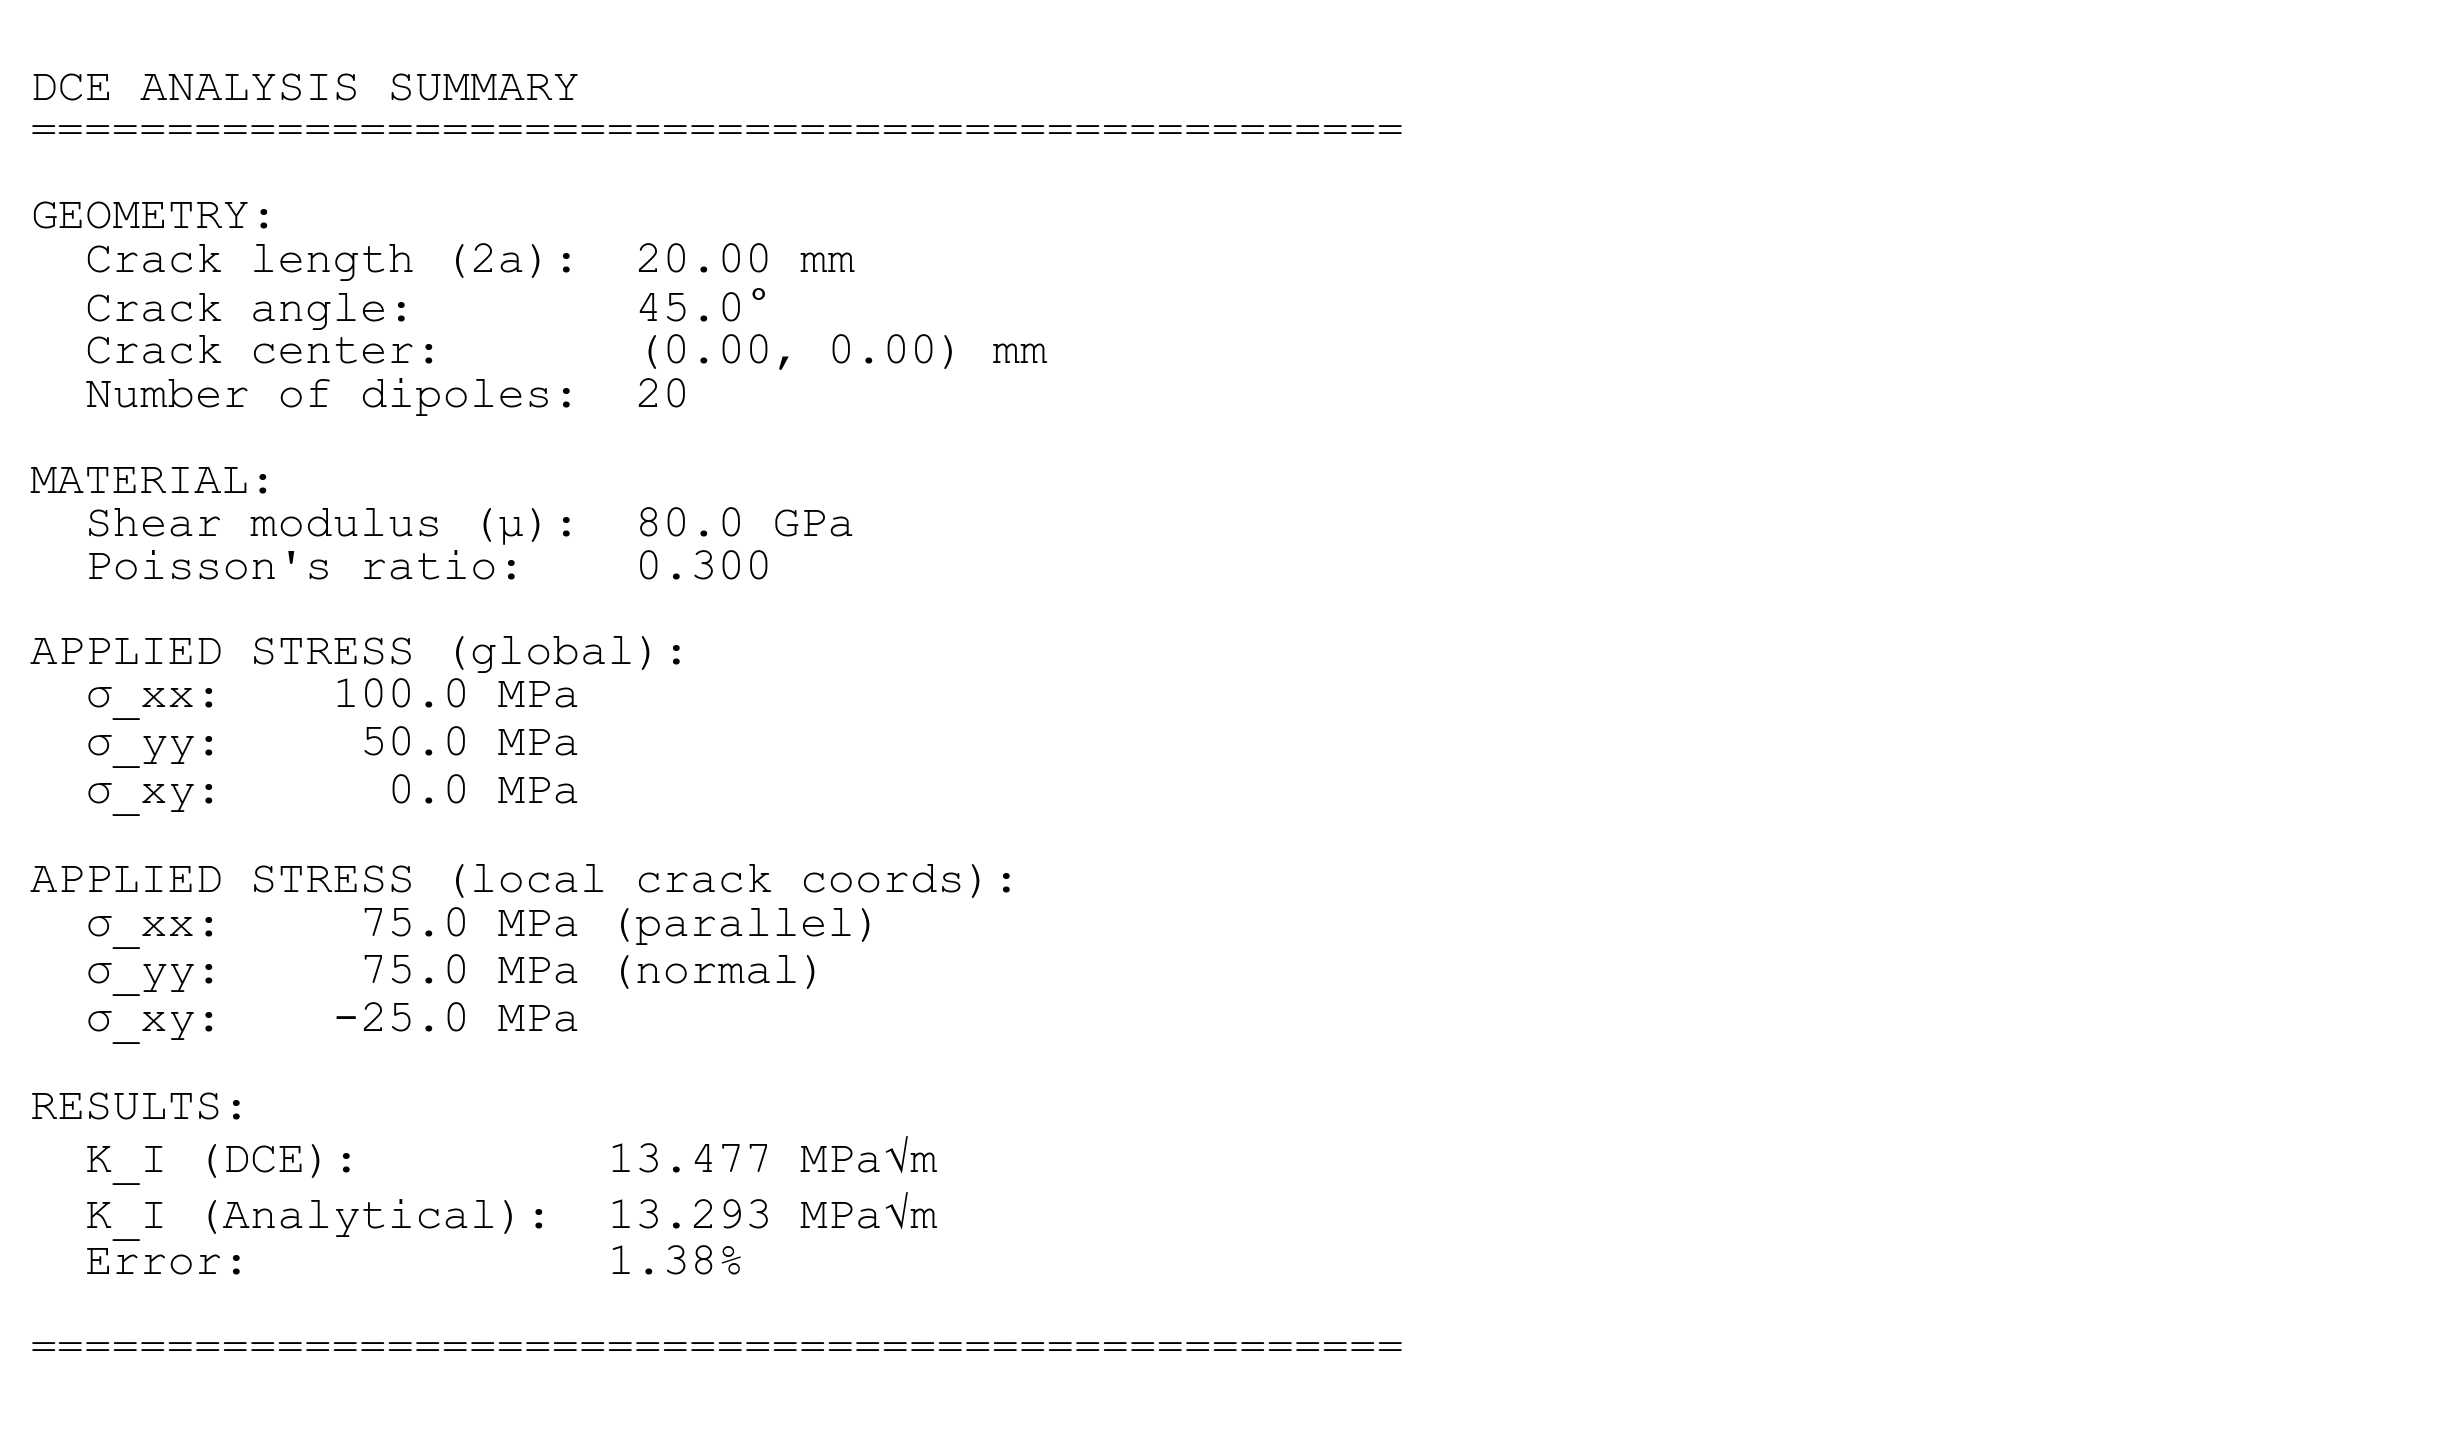


2. Stress fields...
Calculating stress fields on 100x100 grid...
  Done!

  DEBUG COD profile:
    Positions (first 3): [-10.          -9.5         -9.02631579] mm
    Positions (last 3): [ 9.02631579  9.5        10.        ] mm
    COD (first 3): [   0.         4169.11673336 5794.1966954 ] nm
    COD (last 3): [4169.11673336    0.            0.        ] nm
    Smooth array length: 83
    Smooth COD (first): 0.000 nm
    Smooth COD (last): 0.000 nm


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

✓ Saved to C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\dce_results\stress_fields.png


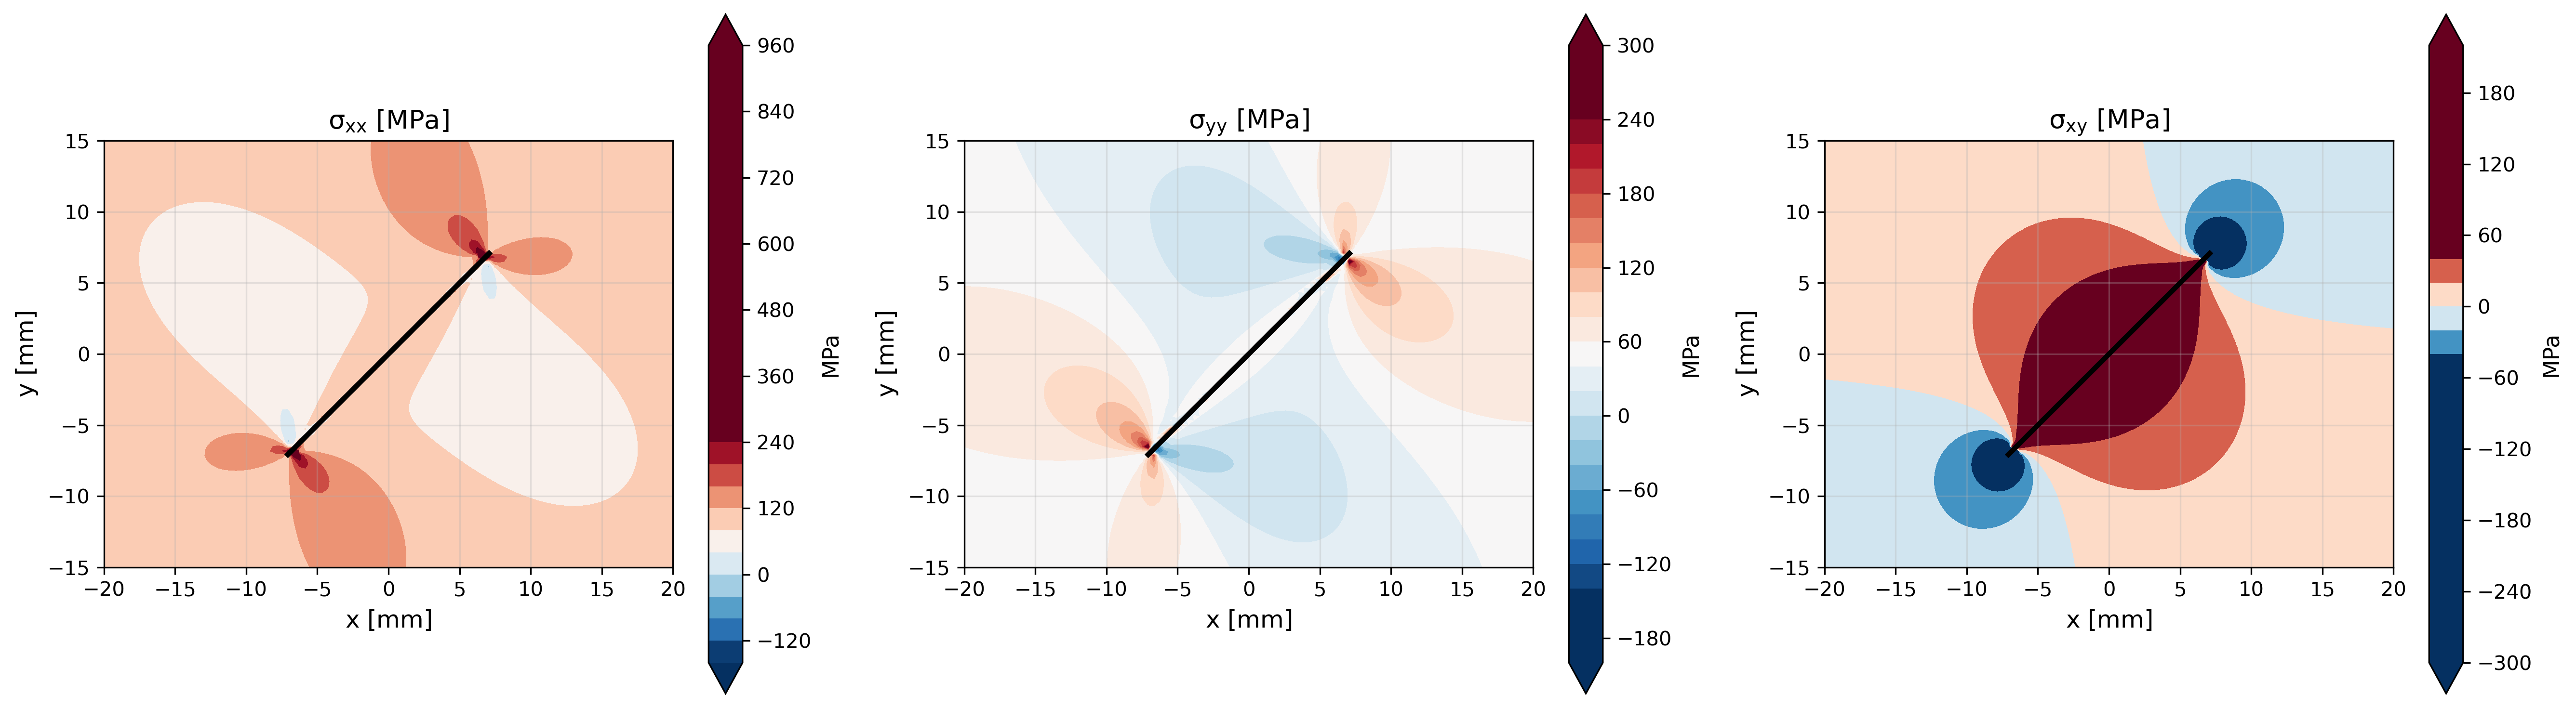


3. Crack opening displacement...
Calculating COD for crack shape visualization...

  DEBUG COD profile:
    Positions (first 3): [-10.          -9.5         -9.02631579] mm
    Positions (last 3): [ 9.02631579  9.5        10.        ] mm
    COD (first 3): [   0.         4169.11673336 5794.1966954 ] nm
    COD (last 3): [4169.11673336    0.            0.        ] nm
    Smooth array length: 83
    Smooth COD (first): 0.000 nm
    Smooth COD (last): 0.000 nm

  Crack angle: 45.0°
  Crack direction (global): [0.707, 0.707]
  Crack normal (global):    [-0.707, 0.707]
  Dot product: -4.266422e-17 (should be ~0)
  Max COD (actual): 13.14 μm
  Scale factor: 304.5x
  Max COD (scaled): 4.00 mm
✓ Saved to C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\dce_results\cod.png


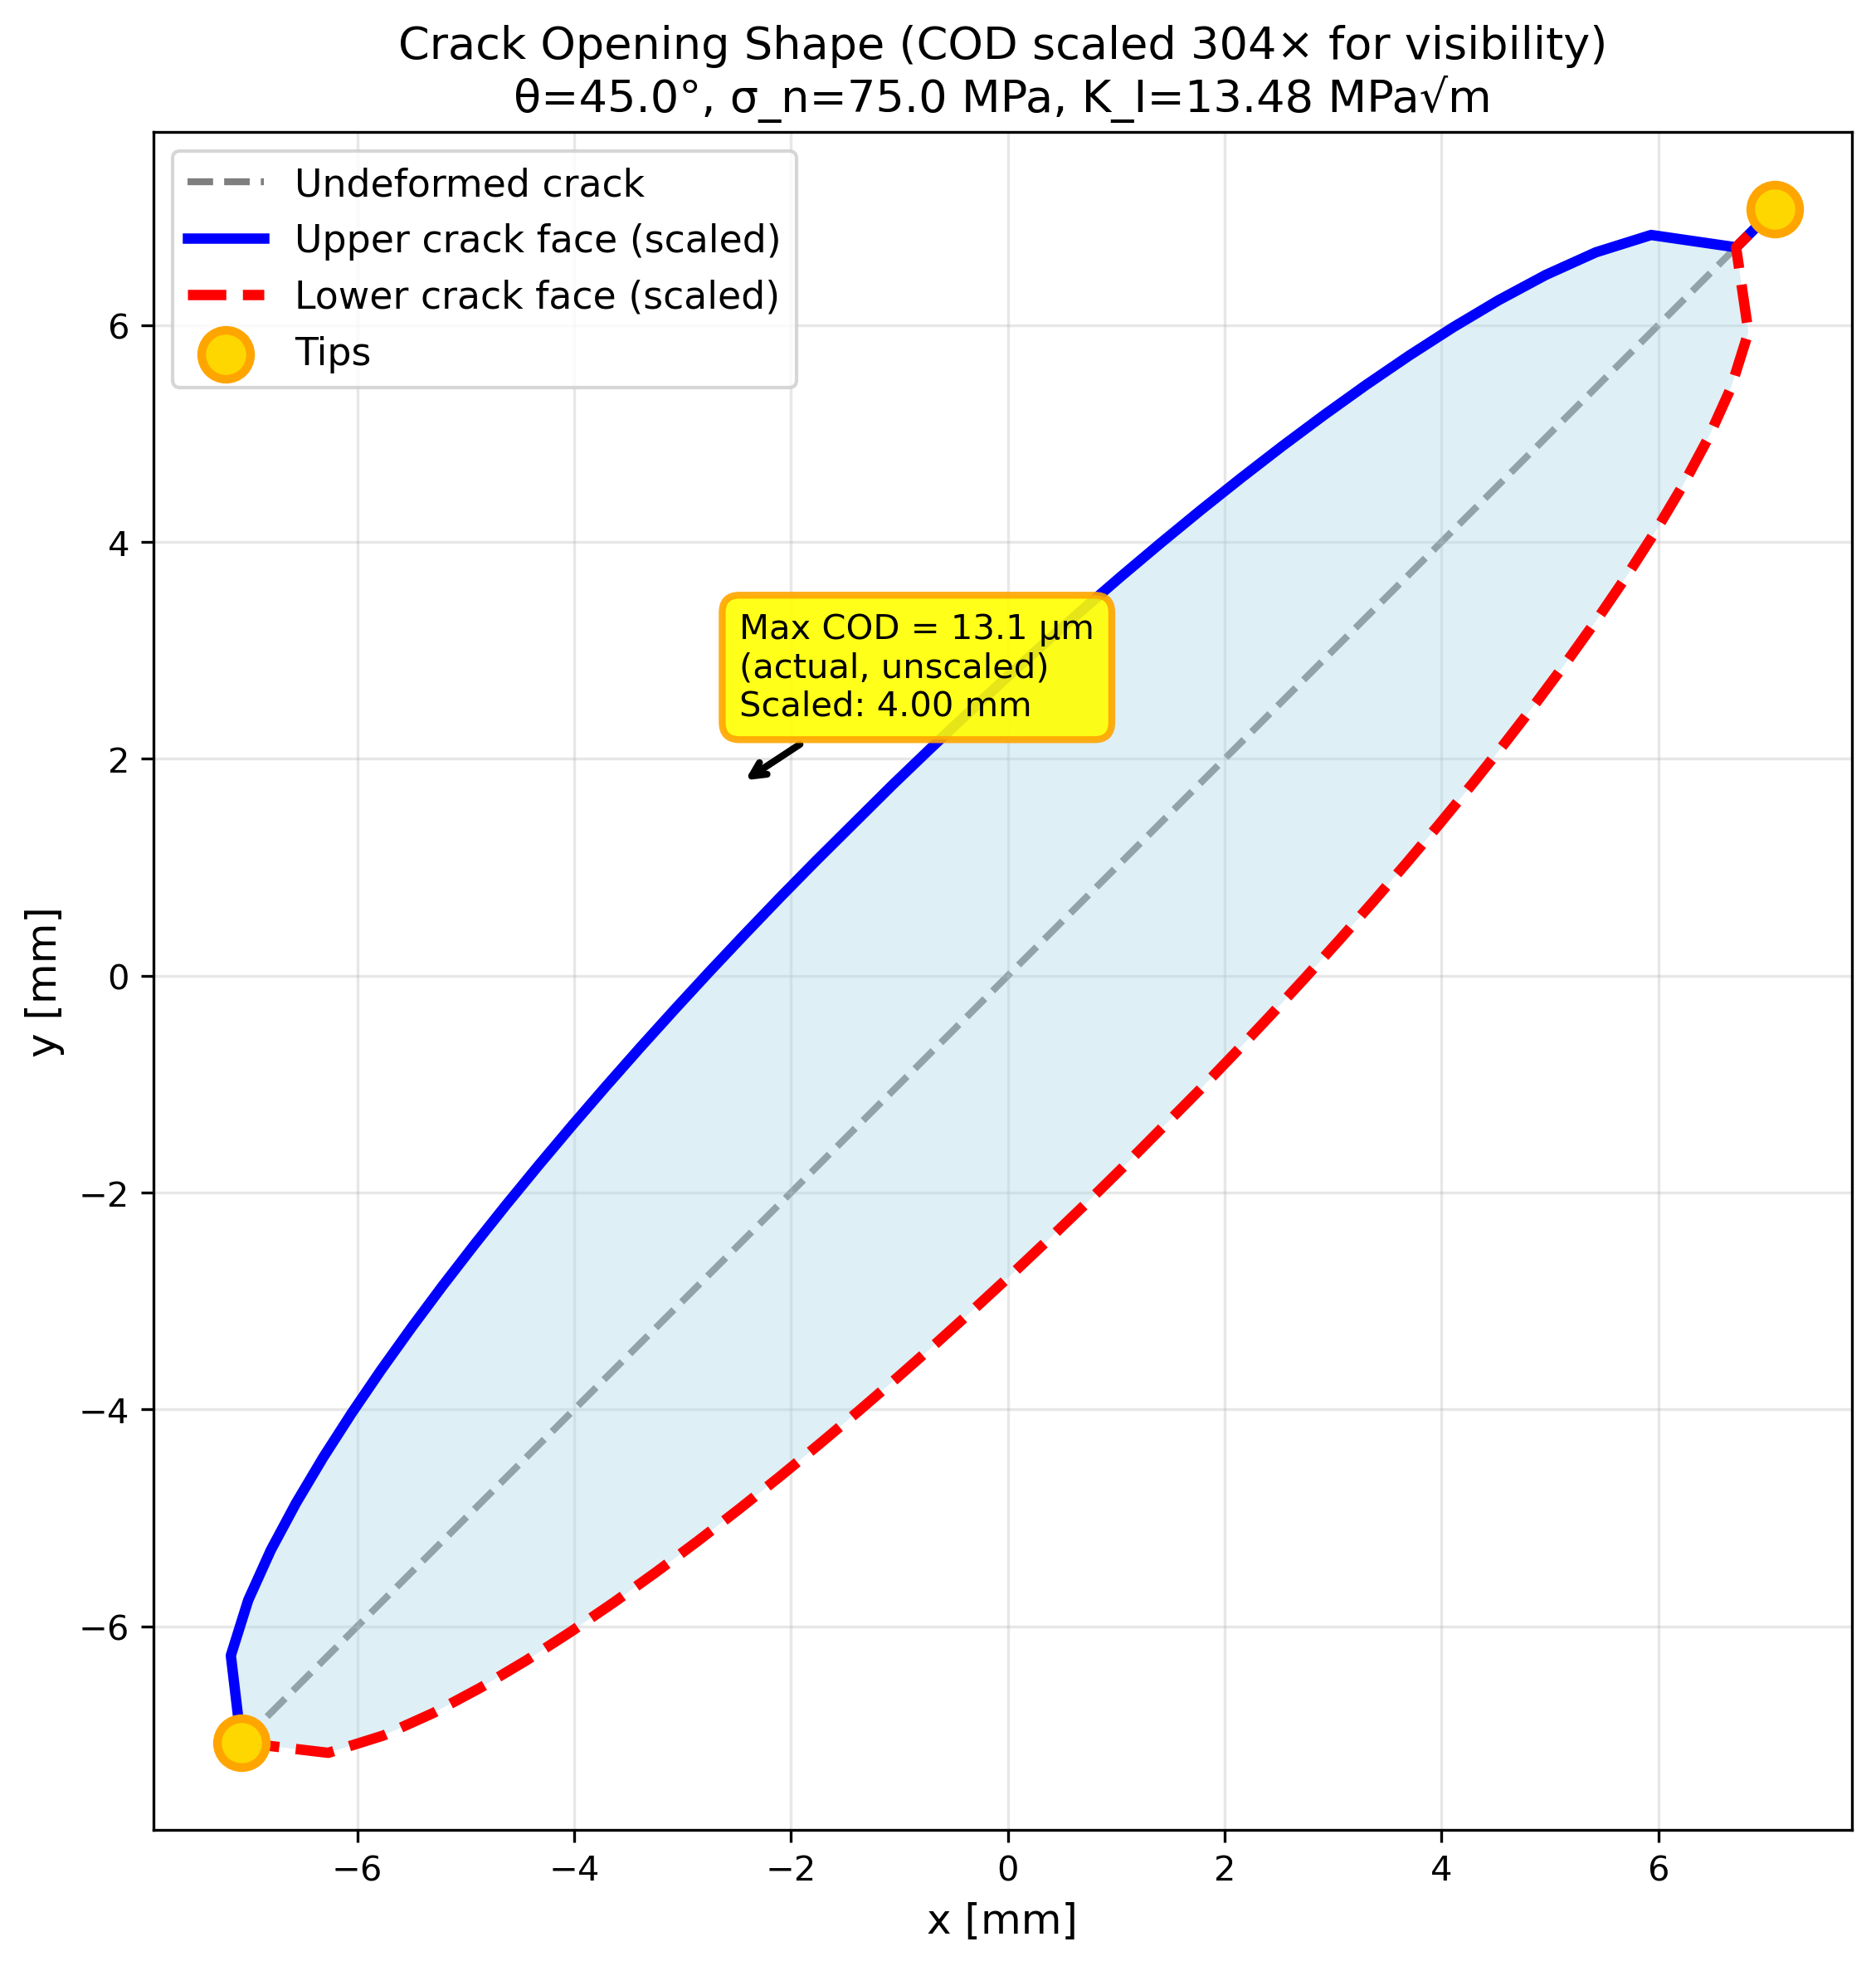


ANALYSIS COMPLETE
All results saved to: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\dce_results


In [2]:
"""
DCE Analysis - Jupyter Notebook
Interactive analysis with customizable inputs
"""

# %% Imports
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os, sys


# Ensure CrackUtils is on path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# Import DCE modules
from CrackUtils.dce_calculations import Material, Crack, AppliedStress, DCECalculator
from CrackUtils.dce_plotting import DCEPlotter

# Configure matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.dpi'] = 300

# %% INPUT PARAMETERS

# Material Properties
material = Material(
    mu=80e9,    # Shear modulus (Pa) - e.g., 80 GPa for steel
    nu=0.3      # Poisson's ratio
)

# Crack Geometry
crack = Crack(
    length=20e-3,              # Total crack length 2a (m) - e.g., 20 mm
    angle=np.deg2rad(45),      # Orientation angle from x-axis (radians) - e.g., 0° = horizontal
    center=(0.0, 0.0)         # Crack center position (m)
)

# Applied Stress Tensor
stress = AppliedStress(
    sigma_xx=100e6,      # Normal stress in x-direction (Pa) - e.g., 0 MPa
    sigma_yy=50e6,    # Normal stress in y-direction (Pa) - e.g., 100 MPa
    sigma_xy=0e6       # Shear stress (Pa) - e.g., 0 MPa
)

# Numerical Parameters
n_dipoles = 20           # Number of dipoles
tip_fraction = 0.95      # Position of outermost dipole (fraction of half-length)
grid_size = 100          # Grid resolution for contour plots

# Output Directory
output_dir = Path('C:\\Users\\Owner\\Documents\\Repos\\Fracture\\MulticracksCpp\\output\\dce_results')
output_dir.mkdir(exist_ok=True)

print("="*70)
print("DCE ANALYSIS CONFIGURATION")
print("="*70)
print(f"\nMaterial: μ = {material.mu/1e9:.1f} GPa, ν = {material.nu:.3f}")
print(f"Crack: 2a = {crack.length*1e3:.1f} mm, θ = {np.rad2deg(crack.angle):.1f}°")
print(f"Stress: σ_xx = {stress.sigma_xx/1e6:.1f} MPa, σ_yy = {stress.sigma_yy/1e6:.1f} MPa, σ_xy = {stress.sigma_xy/1e6:.1f} MPa")
print(f"Dipoles: {n_dipoles}")
print("="*70)

# %% CALCULATIONS

print("\nPerforming DCE calculations...")

# Initialize calculator
calc = DCECalculator(material, crack, stress)

# Solve
results = calc.solve(n_dipoles=n_dipoles, tip_fraction=tip_fraction)

print(f"\n✓ Solution complete!")
print(f"  K_I (DCE):        {results['K_I']/1e6:.3f} MPa√m")
print(f"  K_I (Analytical): {results['K_I_analytical']/1e6:.3f} MPa√m")
print(f"  Error:            {results['error_percent']:.2f}%")

# %% PLOTTING

print("\nGenerating plots...")

# Initialize plotter
plotter = DCEPlotter(calc, results)

# 1. Summary
print("\n1. Summary...")
fig_summary = plotter.plot_summary(output_path=output_dir / 'summary.png')
plt.show()

# 2. Stress Fields
print("\n2. Stress fields...")
fig_stress = plotter.plot_stress_fields(
    grid_size=grid_size,
    output_path=output_dir / 'stress_fields.png'
)
plt.show()

# 3. COD
print("\n3. Crack opening displacement...")
fig_cod = plotter.plot_cod(output_path=output_dir / 'cod.png')
plt.show()

# 4. Polar Stress - Right Tip
# print("\n4. Polar stress (right tip)...")
# fig_polar_right = plotter.plot_polar_stress(
#     tip='right',
#     output_path=output_dir / 'polar_stress_right.png'
# )
# plt.show()

# 5. Polar Stress - Left Tip
# print("\n5. Polar stress (left tip)...")
# fig_polar_left = plotter.plot_polar_stress(
#     tip='left',
#     output_path=output_dir / 'polar_stress_left.png'
# )
# plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print(f"All results saved to: {output_dir.absolute()}")
print("="*70)

# End of notebook